<a href="https://colab.research.google.com/github/reyhanfisena/rainfall-forecasting-pasuruan/blob/main/rainfall_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Prediksi Curah Hujan menggunakan Algoritma LSTM dan PSO di Kabupaten Pasuruan

Penelitian ini dilakukan untuk mengetahui bagaimana PSO dapat meningkatkan kinerja model LSTM dalam memprediksi curah hujan di Kabupaten Pasuruan.
Data yang akan digunakan dalam penelitian ini berasal dari BMKG Stasiun Geofisika Pasuruan diambil melalui website [Data Online BMKG](https://dataonline.bmkg.go.id/dataonline-home) dengan variabel TAVG (suhu udara rata-rata), RH_AVG (kelembapan udara rata-rata), RR (curah hujan).


## Import Library

In [ ]:
!pip install pyswarms -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.1/104.1 kB 6.6 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
import tensorflow as tf


import pyswarms as ps

np.random.seed(42)
tf.random.set_seed(42)

import warnings
warnings.filterwarnings('ignore')

from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load & Cleaning Data

In [ ]:
# Fungsi untuk membaca file csv dan mengembalikan dataframe

def read_csv(file_path):
    return pd.read_csv(file_path, sep=',')


#Target yang digunakan
target_column = ['TANGGAL', 'TAVG', 'RH_AVG', 'RR']

numeric_columns = ['TAVG', 'RH_AVG', 'RR']

In [ ]:
df_cuaca = read_csv('/content/drive/MyDrive/Skripsi/data_cuaca.csv')
df_cuaca

,TANGGAL,TAVG,RH_AVG,RR
0,1/1/2021,21.8,93.0,19.8
1,2/1/2021,21.4,96.0,12.5
2,3/1/2021,21.4,95.0,22.1
3,4/1/2021,20.8,98.0,8.5
4,5/1/2021,20.7,98.0,15.0
...,...,...,...,...
1810,27-12-2025,23.2,9999.0,1.0
1811,28-12-2025,22.7,9999.0,0.1
1812,29-12-2025,22.1,9999.0,0.0
1813,30-12-2025,21.9,9999.0,5.0


Mengubah format tanggal

In [ ]:
# Function to parse dates with multiple formats
def parse_dates(date_str):
    for fmt in ('%d-%m-%Y', '%d/%m/%Y'):
        try:
            return pd.to_datetime(date_str, format=fmt, dayfirst=True)
        except ValueError:
            continue
    return pd.NaT

# Apply the function to convert 'TANGGAL' to datetime
df_cuaca['TANGGAL'] = df_cuaca['TANGGAL'].apply(parse_dates)

# Convert datetime to desired format 'YYYY-MM-DD'
df_cuaca['TANGGAL'] = df_cuaca['TANGGAL'].dt.strftime('%Y-%m-%d')
df_cuaca['TANGGAL'] = pd.to_datetime(df_cuaca['TANGGAL'])

df_cuaca

,TANGGAL,TAVG,RH_AVG,RR
0,2021-01-01,21.8,93.0,19.8
1,2021-01-02,21.4,96.0,12.5
2,2021-01-03,21.4,95.0,22.1
3,2021-01-04,20.8,98.0,8.5
4,2021-01-05,20.7,98.0,15.0
...,...,...,...,...
1810,2025-12-27,23.2,9999.0,1.0
1811,2025-12-28,22.7,9999.0,0.1
1812,2025-12-29,22.1,9999.0,0.0
1813,2025-12-30,21.9,9999.0,5.0


mengubah kode 8888 dan 9999 menjadi kosong (NaN)

In [ ]:
# Function to replace invalid values (8888 and 9999) with NaN
def replace_invalid_values(df, columns_to_clean):
    df_copy = df.copy()
    for col in columns_to_clean:
        df_copy[col] = df_copy[col].replace([8888, 9999], np.nan)
    return df_copy

# Melakukan penggantian nilai 8888 dan 9999 ke nilai NAN
df_cuaca = replace_invalid_values(df_cuaca, numeric_columns)
df_cuaca

,TANGGAL,TAVG,RH_AVG,RR
0,2021-01-01,21.8,93.0,19.8
1,2021-01-02,21.4,96.0,12.5
2,2021-01-03,21.4,95.0,22.1
3,2021-01-04,20.8,98.0,8.5
4,2021-01-05,20.7,98.0,15.0
...,...,...,...,...
1810,2025-12-27,23.2,NaN,1.0
1811,2025-12-28,22.7,NaN,0.1
1812,2025-12-29,22.1,NaN,0.0
1813,2025-12-30,21.9,NaN,5.0


simpan csv

In [ ]:
# Function to save DataFrame to CSV
def save_to_csv(df, file_name):
    df.to_csv(file_name, index=False)
    print(f"DataFrame saved to {file_name}")

# Ganti dengan nama file CSV yang ingin disimpan
save_to_csv(df_cuaca, 'df_cuaca.csv')

DataFrame saved to df_cuaca.csv


Missing values


In [ ]:
# Hitung jumlah missing values pada masing-masing kolom
missing_values = df_cuaca.isnull().sum()

# Hitung persentase missing values
total_values = len(df_cuaca)
missing_percentage = (missing_values / total_values) * 100

# Tampilkan persentase missing values
print("Persentase Missing Values pada Masing-masing Kolom:")
print(missing_percentage)

Persentase Missing Values pada Masing-masing Kolom:
TANGGAL     0.000000
TAVG        6.170799
RH_AVG     42.975207
RR         24.517906
dtype: float64


## Data Preprocessing

In [ ]:
df = read_csv('/content/drive/MyDrive/Skripsi/df_cuaca.csv')

df_cleaned = df[['tanggal', 'tavg', 'rh_avg', 'rr']].copy()

df_cleaned['tanggal'] = pd.to_datetime(df_cleaned['tanggal'])


rename kolom

In [ ]:
df_cleaned.rename(columns={
    'tavg': 'suhu',
    'rh_avg': 'kelembaban',
    'rr': 'curah_hujan'
}, inplace=True)

#tanggal sebagai index
df_cleaned.set_index('tanggal', inplace=True)

# Tampilkan hasil akhirnya
display(df_cleaned.head())

,suhu,kelembaban,curah_hujan
tanggal,,,
2021-01-01,21.8,93.0,19.8
2021-01-02,21.4,96.0,12.5
2021-01-03,21.4,95.0,22.1
2021-01-04,20.8,98.0,8.5
2021-01-05,20.7,98.0,15.0


cek missing value

Jumlah Missing Value Sebelum Imputasi:
 suhu           112
kelembaban     780
curah_hujan    445
dtype: int64


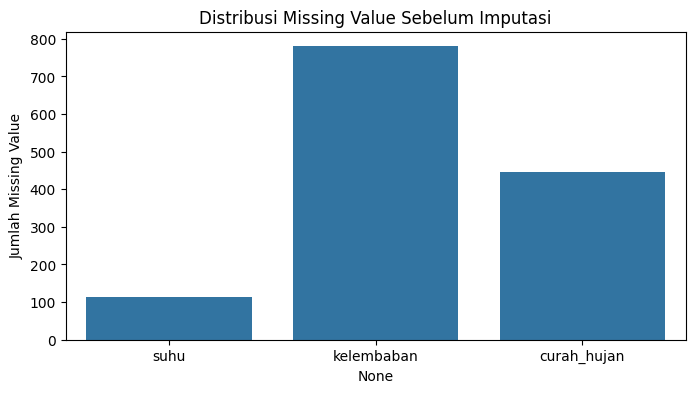

In [ ]:
missing_before = df_cleaned.isnull().sum()
print("Jumlah Missing Value Sebelum Imputasi:\n", missing_before)

plt.figure(figsize=(8, 4))
sns.barplot(x=missing_before.index, y=missing_before.values)
plt.title('Distribusi Missing Value Sebelum Imputasi')
plt.ylabel('Jumlah Missing Value')
plt.show()

Imputasi menggunakan Random Forest

In [ ]:
print("Memulai proses imputasi Random Forest...")

# Capture indices of rows with any NaN values before imputation
nan_indices = df_cleaned[df_cleaned.isnull().any(axis=1)].index

rf_estimator = RandomForestRegressor(n_estimators=10, random_state=42)
imputer = IterativeImputer(estimator=rf_estimator, random_state=42, max_iter=10)

# Lakukan imputasi dan kembalikan ke bentuk dataframe
df_imputed_array = imputer.fit_transform(df_cleaned)
df_imputed = pd.DataFrame(df_imputed_array, columns=df_cleaned.columns, index=df_cleaned.index)

print("=== SESUDAH IMPUTASI (Nilai NaN Telah Terisi) ===")
display(df_imputed.loc[nan_indices])
print("\nPengecekan Akhir Missing Value:")
print(df_imputed.isna().sum())

save_to_csv(df_imputed, 'df_imputed.csv')

Memulai proses imputasi Random Forest...
=== SESUDAH IMPUTASI (Nilai NaN Telah Terisi) ===


,suhu,kelembaban,curah_hujan
tanggal,,,
2021-01-11,22.4,93.000000,12.371333
2021-01-15,21.8,93.000000,42.190000
2021-01-22,20.5,96.000000,35.777500
2021-01-30,20.9,90.000000,2.500000
2021-02-20,21.5,94.000000,16.535143
...,...,...,...
2025-12-27,23.2,86.000000,1.000000
2025-12-28,22.7,89.471176,0.100000
2025-12-29,22.1,84.230557,0.000000



Pengecekan Akhir Missing Value:
suhu           0
kelembaban     0
curah_hujan    0
dtype: int64
DataFrame saved to df_imputed.csv


Normalisasi Data

In [ ]:
scaler = MinMaxScaler(feature_range=(0, 1))

# Fit dan transform data
df_scaled_array = scaler.fit_transform(df_imputed)
df_scaled = pd.DataFrame(df_scaled_array, columns=df_imputed.columns, index=df_imputed.index)

print("Data setelah normalisasi:")
display(df_scaled.head())

Data setelah normalisasi:


,suhu,kelembaban,curah_hujan
tanggal,,,
2021-01-01,0.324786,0.857143,0.122222
2021-01-02,0.290598,0.928571,0.077160
2021-01-03,0.290598,0.904762,0.136420
2021-01-04,0.239316,0.976190,0.052469
2021-01-05,0.230769,0.976190,0.092593


## Sliding Window

In [ ]:
def create_dataset(dataset, look_back=7):
    X, Y = [], []
    for i in range(len(dataset) - look_back):
        X.append(dataset.iloc[i:(i + look_back)].values)
        # Indeks 2 adalah kolom 'curah_hujan'
        Y.append(dataset.iloc[i + look_back]['curah_hujan'])
    return np.array(X), np.array(Y)

# Menggunakan 7 hari ke belakang (sesuai instruksi terbaru)
look_back = 7
X, y = create_dataset(df_scaled, look_back)

print(f"Proses Sliding Window Selesai ({look_back} timestep).")
print(f"Bentuk Keseluruhan Data X: {X.shape}")
print(f"Bentuk Keseluruhan Data y: {y.shape}")

Proses Sliding Window Selesai (7 timestep).
Bentuk Keseluruhan Data X: (1808, 7, 3)
Bentuk Keseluruhan Data y: (1808,)


## Split Data

In [ ]:
train_ratio = 0.8
train_size = int(len(X) * train_ratio)

X_train, X_test = X[0:train_size], X[train_size:len(X)]
y_train, y_test = y[0:train_size], y[train_size:len(y)]

print(f"Skema Pembagian Data: 80 : 20")
print(f"Shape X_train: {X_train.shape}, y_train: {y_train.shape}")
print(f"Shape X_test: {X_test.shape}, y_test: {y_test.shape}")

Skema Pembagian Data: 80 : 20
Shape X_train: (1446, 7, 3), y_train: (1446,)
Shape X_test: (362, 7, 3), y_test: (362,)


## Modeling

Arsitektur LSTM

In [ ]:
def build_lstm_baseline(neurons=64, learning_rate=0.01, dropout_rate=0.2):
    model = Sequential()

    model.add(LSTM(neurons, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(LSTM(neurons))
    model.add(Dropout(dropout_rate))
    model.add(Dense(1))

    # Kompilasi
    optimizer = Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer, loss='mse', metrics=[tf.keras.metrics.RootMeanSquaredError(name='rmse')])

    return model

# Menampilkan Summary Arsitektur Baseline
baseline_model = build_lstm_baseline()
print("=== ARSITEKTUR MODEL BASELINE ===")
baseline_model.summary()

=== ARSITEKTUR MODEL BASELINE ===


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 7, 64)          │        17,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,497 (197.25 KB)

 Trainable params: 50,497 (197.25 KB)

 Non-trainable params: 0 (0.00 B)

## Optimasi PSO